In [2]:
#Import Pandas
import pandas as pd

In [3]:
# Read Csv File
df=pd.read_csv("/kaggle/input/datasets/sp23bse071/studentperformance/student_performance.csv")

In [4]:
df.head()

,Student_ID,Name,Age,Program,Python,Mathematics,Statistics,Machine_Learning,Attendance
0,S001,Ali Khan,20,AI,85,78,92,88,95
1,S002,Sara Ahmed,21,AI,72,75,70,80,90
2,S003,Ahmed Raza,22,SE,90,88,91,93,96
3,S004,Fatima Noor,20,DS,65,70,68,72,85
4,S005,Usman Ali,21,AI,78,82,80,76,88


In [5]:
# Do one-hot encoding 
df = pd.get_dummies(df, columns=['Program'])

In [6]:
df.head(5)

,Student_ID,Name,Age,Python,Mathematics,Statistics,Machine_Learning,Attendance,Program_AI,Program_DS,Program_SE
0,S001,Ali Khan,20,85,78,92,88,95,True,False,False
1,S002,Sara Ahmed,21,72,75,70,80,90,True,False,False
2,S003,Ahmed Raza,22,90,88,91,93,96,False,False,True
3,S004,Fatima Noor,20,65,70,68,72,85,False,True,False
4,S005,Usman Ali,21,78,82,80,76,88,True,False,False


In [7]:
# Create New column of Average_Score
df['Average_Score']=(df['Python']+df['Mathematics']+df['Statistics']+df['Machine_Learning'])/4

In [8]:
df.head(5)

,Student_ID,Name,Age,Python,Mathematics,Statistics,Machine_Learning,Attendance,Program_AI,Program_DS,Program_SE,Average_Score
0,S001,Ali Khan,20,85,78,92,88,95,True,False,False,85.75
1,S002,Sara Ahmed,21,72,75,70,80,90,True,False,False,74.25
2,S003,Ahmed Raza,22,90,88,91,93,96,False,False,True,90.50
3,S004,Fatima Noor,20,65,70,68,72,85,False,True,False,68.75
4,S005,Usman Ali,21,78,82,80,76,88,True,False,False,79.00


In [9]:
# Select input and Output Features
X = df[['Python', 'Mathematics', 'Statistics', 'Machine_Learning']]
y = df['Average_Score']

In [10]:
# Split test and Train Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16, 4)
(4, 4)
(16,)
(4,)


In [12]:
# Perform Standarization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
# Import Model
model = LinearRegression()

In [15]:
model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)

In [17]:
# Compare them
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison

,Actual,Predicted
0,85.75,85.75
17,97.25,97.25
15,89.50,89.50
1,74.25,74.25


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae) 

MAE: 0.0


In [20]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.0


In [21]:
# R^2 Error
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 1.0


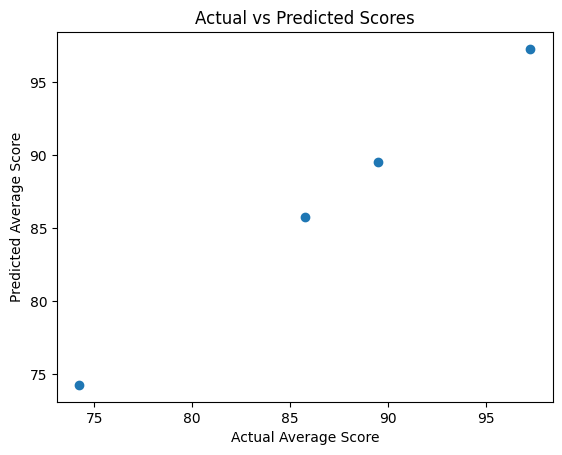

In [24]:
# Visualize Data (Actual and Predicted)
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Average Score")
plt.ylabel("Predicted Average Score")
plt.title("Actual vs Predicted Scores")

plt.show()